# Statistics Foundations

## 1. Exploration


## Statistics

Statistics is an umbrella term for a lot of different activities involving data.

**Statistical Thinking** is needed at every stage of a research project:

* Formulation of hypotheses
* Planning and design of the study
* Data collection
* Data processing
* Data exploration
* Data analysis
* Interpretation of results
* Presentation of results


## Sampling

The data that we work with has to be collected in some way.

In almost every situation, we will not have access to complete information about the things we are studying. We will have to make do with a partial view.



The things that we have data for are called the **sample**.



The complete set of things that we would like to learn about in our study make up the **population**. 



In some cases the population is in principle infinite because the object of study is a process that can be repeated as many times as we like (e.g. rolling a die).


The sample is a part of the population, often just a very tiny part.

### Sampling Strategies

When working with a finite population, there are many ways that we could choose the individuals that we sample, e.g.:



**Convenience sampling**
- choose those easiest to access



**Simple random sampling**
- every individual has the same probability of being chosen


**Stratified random sampling**
- identify subpopulations, then build a random sample so that each subpopulation makes up the same proportion in the sample as it does in the population

**Systematic sampling**
- order the population in some way and choose individuals at regular intervals from the list

## Areas of Statistics

It is helpful to distinguish between two quite different kinds of activity, both of which are thought of as "doing statistics".

### Descriptive Statistics
This is the set of tools for exploring, summarising and presenting information about the *sample* itself.

A **statistic** is a number that we calculate from the sampled data in order to summarise it in some way, e.g.

* the sample mean, $\bar{x}$
* the sample standard deviation, $s$


### Inferential Statistics
This is the set of tools that we use to draw conclusions about the *population*, based on the data that we have collected.

A **parameter** is a number that describes the population in some way. It forms part of a theoretical model for the population and cannot be directly observed, e.g.:

* the population mean, $\mu$
* the population standard deviation, $\sigma$

## Data

Data comes in two basic flavours and each flavour has two subtypes.


**Quantitative Data** are numerical, arising from *counting* or *measurement* processes.

**Categorical Data** (also known as *factors*) are simply labels that we use to define groups of individuals.

### Quantitative Data

There are two types of quantitative data:

**Continuous Data** are measurements with values that can be placed somewhere on a defined interval. 

They may be more or less *precise*, often depending on the precision of the equipment used for measurement.

Examples include:
* blood pressure of a patient
* thickness of a steel sheet
* mass of a planet

**Discrete Data** are also numerical, but are only allowed to take values from a defined set. 

For counting processes, this will often be the set of *non-negative integers*, but some measurement processes can also produce discrete data.

Examples include:
* number of insects caught in a trap in one night
* number of neutrino interactions detected in one hour
* excitation level of a hydrogen atom

### Categorical Data

There are also two types of categorical data:

**Nominal Data** have values taken from a set of category labels that has no meaningful ordering.

Examples include:
* type of a rock (sedimentary/igneous/metamorphic)
* species of an insect
* manufacturer of a resistor
* binary data (yes/no, true/false etc.)


**Ordinal Data** have values taken from a set of labels that *does* have a meaningful order, but *no* meaningful quantitative relationship between labels.

Examples include:
* grade of a tumour (1/2/3/4)
* developmental stage of a fly (egg/larva/pupa/adult)
* level of agreement with a statement (e.g. on a [Likert scale](https://en.wikipedia.org/wiki/Likert_scale))

## Loading data

We will start with some data stored in a simple tabular format called [CSV](https://en.wikipedia.org/wiki/Comma-separated_values) (Comma-separated values).

The data file is located at `data/penguins_size.csv`


```
species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
Adelie,Torgersen,39.1,18.7,181,3750,MALE
Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
Adelie,Torgersen,40.3,18,195,3250,FEMALE
Adelie,Torgersen,NA,NA,NA,NA,NA
Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
Adelie,Torgersen,39.3,20.6,190,3650,MALE
Adelie,Torgersen,38.9,17.8,181,3625,FEMALE
Adelie,Torgersen,39.2,19.6,195,4675,MALE
Adelie,Torgersen,34.1,18.1,193,3475,NA
...
```



This is a dataset about penguins in Antarctica. You can read more about it [here](https://allisonhorst.github.io/palmerpenguins/).

We will use the [`pandas`](https://pandas.pydata.org) package in python to work with tabular data.

The table of data is held as an object called a [`DataFrame`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html#pandas.DataFrame)

In [213]:
import pandas as pd

penguins = pd.read_csv("data/penguins_size.csv")
penguins.head(9)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,MALE
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN


Each column in the table is one variable.

Each row in the table is one individual (data point).

<div>
<img src="figures/culmen.jpeg" width="400"/>
</div>

A one-dimensional [`Series`](https://pandas.pydata.org/docs/reference/series.html) object represents a single variable:

In [214]:
penguins['island']

0      Torgersen
1      Torgersen
2      Torgersen
3      Torgersen
4      Torgersen
         ...    
339       Biscoe
340       Biscoe
341       Biscoe
342       Biscoe
343       Biscoe
Name: island, Length: 344, dtype: object

### Missing data

Notice that a few of the values in the table are missing, shown as `NaN` in python.

It is a good idea to check how many of these there are for each variable.

Unexpected missing values may sometimes indicate problems in reading the data from the file.

In [215]:
penguins.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

## Exploring Data with Python

We will be using some visualisation tools from the [`matplotlib`](https://matplotlib.org/stable/) python package.

For many of the plots that we make, there are convenient methods accessible directly on the `pandas` data objects.

Sometimes we will have to work directly with `matplotlib`, which needs a bit more work.

This course will not be focusing on the details of either `pandas` or `matplotlib` - other training is available for both of these!

However, you will be able to learn from the example code how to do the basics.

## Exploring Categorical Data

### Frequency Table
When working with categorical data, a frequency table is the most direct way to summarise the sample.

We can use a `Series` to show the counts for a single variable:

In [216]:
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

We can also make a cross-tabulation, e.g. to see which species live on which islands:

In [217]:
pd.crosstab(penguins['island'], columns=penguins['species'])

species,Adelie,Chinstrap,Gentoo
island,,,
Biscoe,44,0,124
Dream,56,68,0
Torgersen,52,0,0


### Pie Chart

This is a simple way of giving a general impression of the relative proportions of each category. 



It is difficult to read accurately as it is very hard to compare angles by eye.

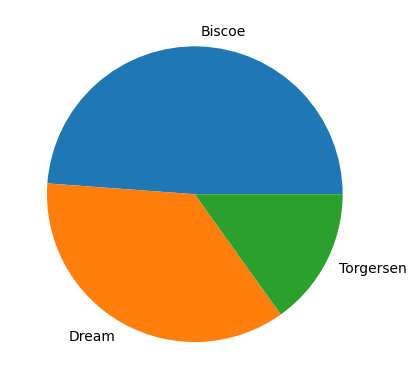

In [218]:
penguins['island'].value_counts() \
    .plot.pie(ylabel='')
plt.show()

### Bar Chart
A much more easily readable version of the data is given by a bar chart.



There is one bar per category and the height of the bar is proportional to the count.

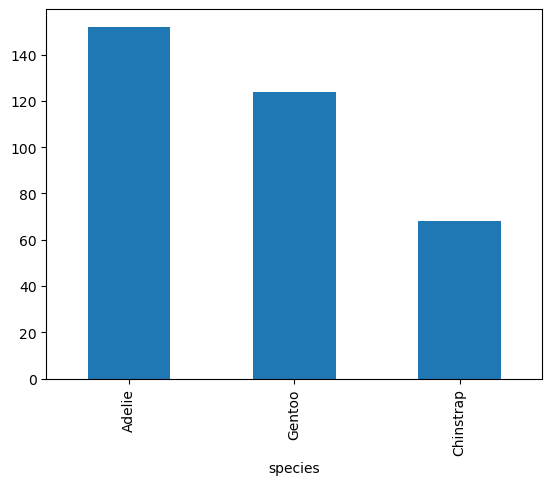

In [219]:
penguins['species'].value_counts() \
    .plot.bar()
plt.show()

We can represent multiple count series as a side-by-side bar chart ...

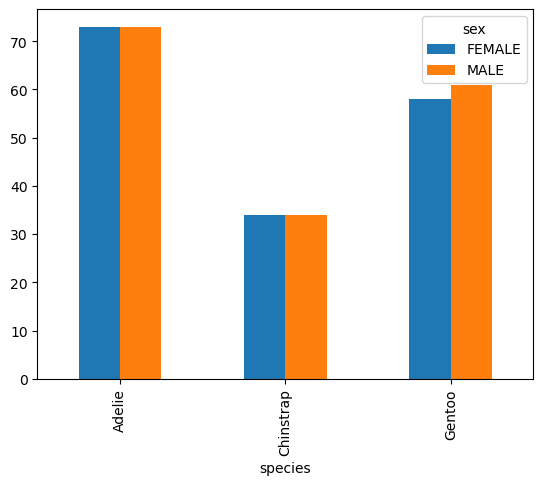

In [220]:
pd.crosstab(penguins['species'], columns=penguins['sex']) \
    .plot.bar()
plt.show()

... or as a stacked bar chart.

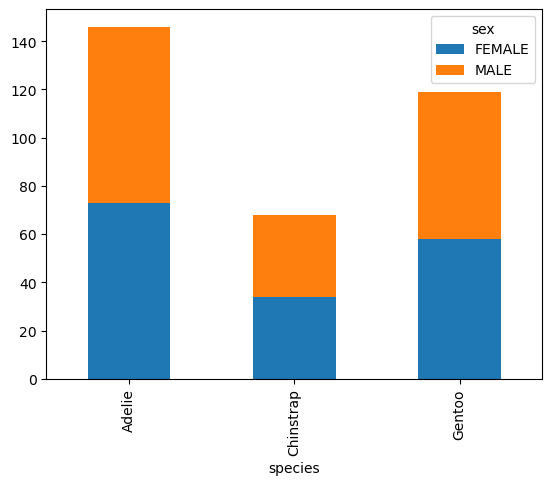

In [221]:
pd.crosstab(penguins['species'], columns=penguins['sex']) \
    .plot.bar(stacked=True)
plt.show()

## Exploring Quantitative Data

### Histogram

A histogram is a simple way to visualise the distribution of a quantitative variable.


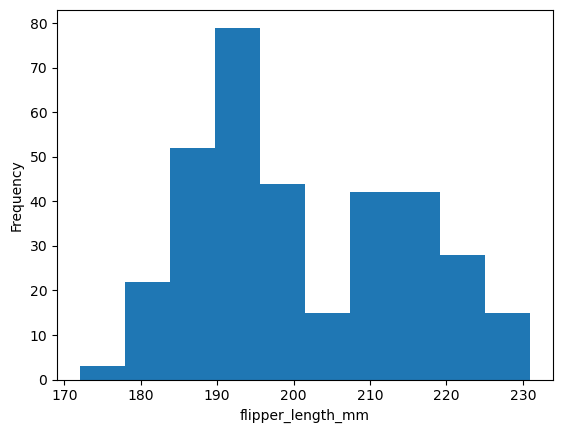

In [222]:
penguins['flipper_length_mm'] \
    .plot.hist(xlabel='flipper_length_mm')
plt.show()


The x-axis is split into chunks called *bins*.

The area drawn in each bin is proportional to the number of data that fall into that bin.



*Usually* we work with histograms that have equal bin width, in which case the y-axis can be marked directly as a frequency.



*However* histograms with unequal bin widths are sometimes used for special purposes.


Sometimes we want to show multiple histograms on the same axes:

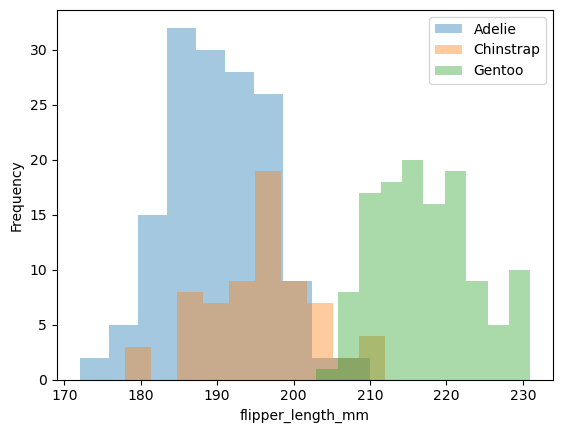

In [223]:
penguins.groupby('species')['flipper_length_mm'].plot.hist(alpha=0.4, 
                                                     xlabel='flipper_length_mm',
                                                     legend=True)
plt.show()

### Violin Plot
A more readable way of comparing distributions for subpopulations is to use a violin plot.


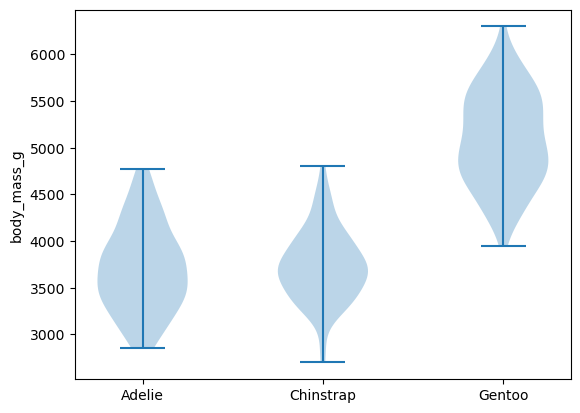

In [224]:
adelie=penguins[penguins['species'] == "Adelie"].dropna()
chinstrap=penguins[penguins['species'] == "Chinstrap"].dropna()
gentoo=penguins[penguins['species'] == "Gentoo"].dropna()

fig, axs = plt.subplots()
plt.violinplot([adelie['body_mass_g'].values,
                chinstrap['body_mass_g'].values,
                gentoo['body_mass_g'].values])
axs.set_xticks([1,2,3])
axs.set_xticklabels(['Adelie','Chinstrap','Gentoo'])
axs.set_ylabel("body_mass_g")

plt.show()

Each histogram is smoothed using [kernel density estimation](https://en.wikipedia.org/wiki/Kernel_density_estimation) (KDE) and mirrored to produce a "violin" shape. The minimum and maximum are also shown here.

### Scatter Plot
To explore the relationship between two quantitative variables, we can use a scatter plot.

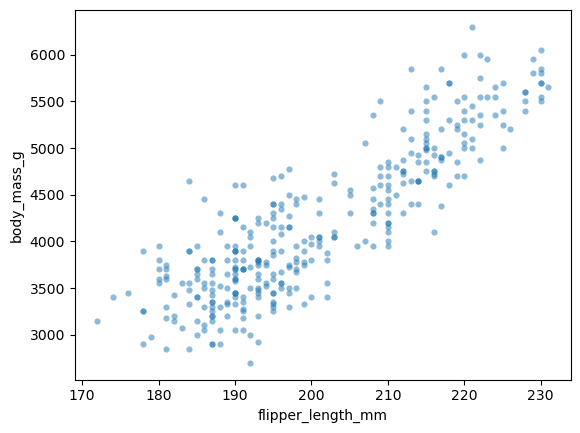

In [225]:
penguins.plot.scatter(x='flipper_length_mm', 
                      y='body_mass_g',
                      linewidth=0, 
                      alpha=0.5)
plt.show()

Each data point is shown with a marker, located on an x-y plane defined by the two variables of interest.

We can colour the data points in various ways.

Representing a quantitative variable on a colour map:

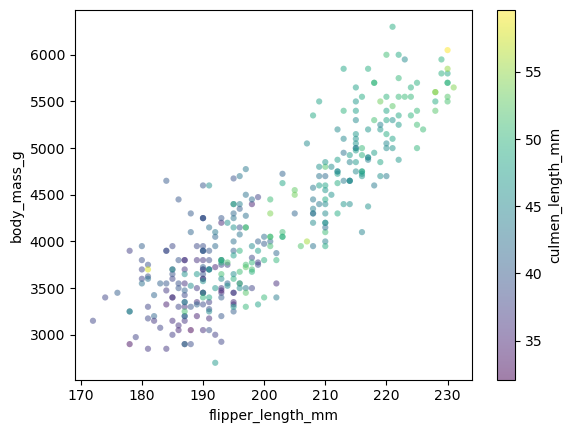

In [226]:
penguins.plot.scatter(x='flipper_length_mm', 
                      y='body_mass_g',
                      linewidth=0, 
                      alpha=0.5, c='culmen_length_mm',
                      colormap="viridis")
plt.show()

Representing a categorical variable using a small set of colours:

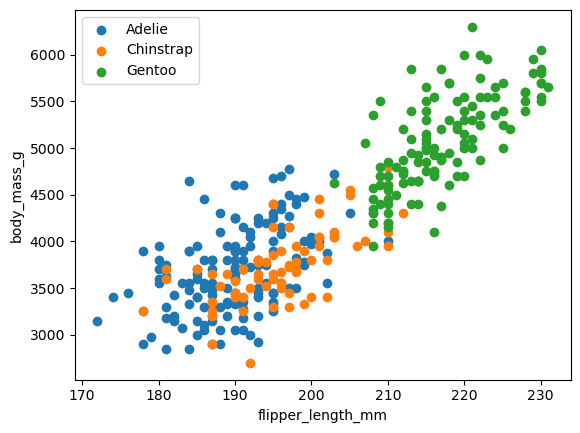

In [227]:
adelie=penguins[penguins['species'] == "Adelie"]
chinstrap=penguins[penguins['species'] == "Chinstrap"]
gentoo=penguins[penguins['species'] == "Gentoo"]

fig, axs = plt.subplots()
plt.scatter(adelie['flipper_length_mm'], adelie['body_mass_g'], label='Adelie')
plt.scatter(chinstrap['flipper_length_mm'], chinstrap['body_mass_g'], label='Chinstrap')
plt.scatter(gentoo['flipper_length_mm'], gentoo['body_mass_g'], label='Gentoo')
axs.set_xlabel('flipper_length_mm')
axs.set_ylabel('body_mass_g')
axs.legend()

plt.show()

### Scatter Matrix

For a set of quantitative variables, this is a convenient way to view all of the histograms together with scatter plots showing the relationship between every pair of variables.


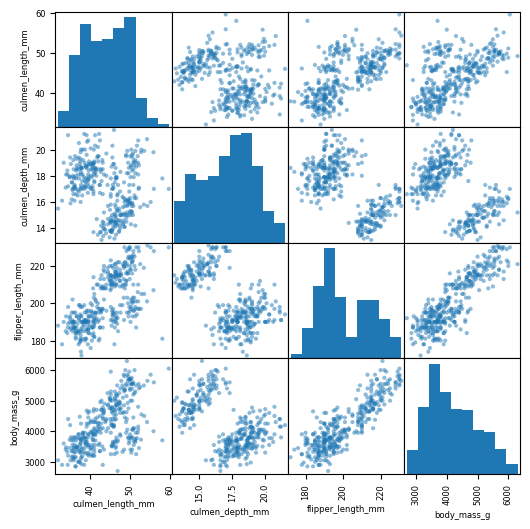

In [228]:
axs = pd.plotting.scatter_matrix(penguins, figsize=(6, 6))
for ax in axs.flatten():
    ax.tick_params(labelsize=6)
    ax.xaxis.label.set_size(6)
    ax.yaxis.label.set_size(6)


plt.show()